In [1]:
!pip install -q kagglehub ultralytics pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 2.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import shutil
import random
import xml.etree.ElementTree as ET
from collections import Counter
import yaml

# Define the project root directory
project_root = Path("/content/safety_helmet_project")

# Define project folders
raw_data_path = project_root / "raw_data"
dataset_path = project_root / "dataset"
outputs_path = project_root / "outputs"
models_path = project_root / "models"
reports_path = project_root / "reports"

# Create project folders
for folder in [
    raw_data_path,
    dataset_path,
    outputs_path,
    models_path,
    reports_path
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Clean project structure created.")
print("Project path:", project_root)


Clean project structure created.
Project path: /content/safety_helmet_project


In [3]:
import kagglehub

# Download the Hard Hat Detection dataset
downloaded_path = kagglehub.dataset_download(
    "andrewmvd/hard-hat-detection"
)

print("Dataset downloaded successfully.")
print("Downloaded path:", downloaded_path)


100%|██████████| 1.22G/1.22G [00:16<00:00, 80.5MB/s]

Extracting files...


Dataset downloaded successfully.
Downloaded path: /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1


In [4]:
from pathlib import Path

# Convert the downloaded dataset path into a Path object
downloaded_path = Path(downloaded_path)

# Find all image files
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = [
    file
    for file in downloaded_path.rglob("*")
    if file.is_file()
    and file.suffix.lower() in image_extensions
]

# Find all Pascal VOC XML annotation files
xml_files = [
    file
    for file in downloaded_path.rglob("*.xml")
    if file.is_file()
]

print("Dataset path:", downloaded_path)
print("Images found:", len(image_files))
print("XML annotation files found:", len(xml_files))


Dataset path: /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1
Images found: 5000
XML annotation files found: 5000


In [5]:
# Count the object classes stored in the XML files
original_class_counts = {}

for xml_file in xml_files:

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for object_element in root.findall("object"):

        name_element = object_element.find("name")

        if name_element is None:
            continue

        class_name = name_element.text.strip().lower()

        if class_name not in original_class_counts:
            original_class_counts[class_name] = 0

        original_class_counts[class_name] += 1

print("Original dataset classes:")

for class_name, count in sorted(original_class_counts.items()):
    print(f"{class_name}: {count}")


Original dataset classes:
head: 5785
helmet: 18966
person: 751


In [6]:
# Create a lookup table for XML annotation files
xml_map = {
    xml_file.stem: xml_file
    for xml_file in xml_files
}

# Find image/XML pairs
matched_pairs = []

for image_file in image_files:

    matching_xml = xml_map.get(image_file.stem)

    if matching_xml is not None:
        matched_pairs.append((image_file, matching_xml))

print("Matched image/XML pairs:", len(matched_pairs))
print("Images without XML annotations:", len(image_files) - len(matched_pairs))


Matched image/XML pairs: 5000
Images without XML annotations: 0


In [7]:
import random

# Make the selection reproducible
random.seed(42)

# Shuffle the image/XML pairs
random.shuffle(matched_pairs)

# Select a maximum of 300 pairs
selected_pairs = matched_pairs[:300]

print("Selected image/XML pairs:", len(selected_pairs))


Selected image/XML pairs: 300


In [8]:
selected_class_counts = Counter()
images_per_class = Counter()

for image_file, xml_file in selected_pairs:

    image_classes = set()

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for object_element in root.findall("object"):

        name_element = object_element.find("name")

        if name_element is None:
            continue

        class_name = name_element.text.strip().lower()

        if class_name in {"person", "helmet", "head"}:
            selected_class_counts[class_name] += 1
            image_classes.add(class_name)

    for class_name in image_classes:
        images_per_class[class_name] += 1

print("Objects in selected images:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{selected_class_counts[class_name]} objects"
    )

print("\nImages containing each class:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{images_per_class[class_name]} images"
    )


Objects in selected images:
person: 58 objects
helmet: 998 objects
head: 348 objects

Images containing each class:
person: 13 images
helmet: 268 images
head: 58 images


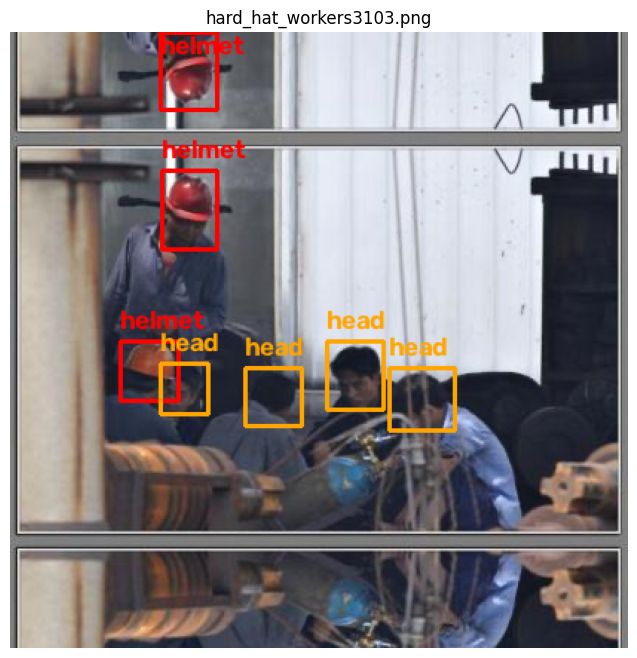

In [9]:
import cv2
import matplotlib.pyplot as plt

# Select the first image/XML pair
sample_image_file, sample_xml_file = selected_pairs[0]

# Read the image
image = cv2.imread(str(sample_image_file))

if image is None:
    raise ValueError("The sample image could not be read.")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get image dimensions
image_height, image_width = image.shape[:2]

# Read the XML annotation
tree = ET.parse(sample_xml_file)
root = tree.getroot()

for object_element in root.findall("object"):

    name_element = object_element.find("name")

    if name_element is None:
        continue

    class_name = name_element.text.strip().lower()

    if class_name not in {"person", "helmet", "head"}:
        continue

    box_element = object_element.find("bndbox")

    xmin = int(float(box_element.find("xmin").text))
    ymin = int(float(box_element.find("ymin").text))
    xmax = int(float(box_element.find("xmax").text))
    ymax = int(float(box_element.find("ymax").text))

    if class_name == "person":
        color = (0, 255, 0)
    elif class_name == "helmet":
        color = (255, 0, 0)
    else:
        color = (255, 165, 0)

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        color,
        2
    )

    cv2.putText(
        image,
        class_name,
        (xmin, max(ymin - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title(sample_image_file.name)
plt.show()


In [10]:
from collections import defaultdict
import random
import xml.etree.ElementTree as ET

# Group image/XML pairs according to the classes they contain
pairs_by_class = defaultdict(list)

for image_file, xml_file in matched_pairs:

    classes_in_image = set()

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for object_element in root.findall("object"):

        name_element = object_element.find("name")

        if name_element is None:
            continue

        class_name = name_element.text.strip().lower()

        if class_name in {"person", "helmet", "head"}:
            classes_in_image.add(class_name)

    for class_name in classes_in_image:
        pairs_by_class[class_name].append((image_file, xml_file))

print("Images available by class in the complete dataset:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{len(pairs_by_class[class_name])} images"
    )


Images available by class in the complete dataset:
person: 158 images
helmet: 4581 images
head: 920 images


In [11]:
# Use a fixed seed for reproducible selection
random.seed(42)

# Shuffle each class group
for class_name in ["person", "helmet", "head"]:
    random.shuffle(pairs_by_class[class_name])

# Target images for each class
target_person_images = 100
target_helmet_images = 100
target_head_images = 100

# Select images from each class
balanced_candidates = (
    pairs_by_class["person"][:target_person_images]
    + pairs_by_class["helmet"][:target_helmet_images]
    + pairs_by_class["head"][:target_head_images]
)

# Remove duplicate images while preserving order
selected_pairs_balanced = []
selected_image_names = set()

for image_file, xml_file in balanced_candidates:

    if image_file.name not in selected_image_names:
        selected_pairs_balanced.append((image_file, xml_file))
        selected_image_names.add(image_file.name)

# If duplicates reduce the total below 300, fill from remaining dataset
if len(selected_pairs_balanced) < 300:

    remaining_pairs = [
        pair
        for pair in matched_pairs
        if pair[0].name not in selected_image_names
    ]

    random.shuffle(remaining_pairs)

    for image_file, xml_file in remaining_pairs:

        selected_pairs_balanced.append((image_file, xml_file))
        selected_image_names.add(image_file.name)

        if len(selected_pairs_balanced) == 300:
            break

# Replace the old random selection
selected_pairs = selected_pairs_balanced[:300]

print("Final selected image/XML pairs:", len(selected_pairs))


Final selected image/XML pairs: 300


In [12]:
# Recalculate class counts for the new selected dataset
selected_class_counts = Counter()
images_per_class = Counter()

for image_file, xml_file in selected_pairs:

    classes_in_current_image = set()

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for object_element in root.findall("object"):

        name_element = object_element.find("name")

        if name_element is None:
            continue

        class_name = name_element.text.strip().lower()

        if class_name in {"person", "helmet", "head"}:

            selected_class_counts[class_name] += 1
            classes_in_current_image.add(class_name)

    for class_name in classes_in_current_image:
        images_per_class[class_name] += 1

print("Objects in the new selected dataset:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{selected_class_counts[class_name]} objects"
    )

print("\nImages containing each class in the new selection:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{images_per_class[class_name]} images"
    )


Objects in the new selected dataset:
person: 498 objects
helmet: 1027 objects
head: 649 objects

Images containing each class in the new selection:
person: 103 images
helmet: 251 images
head: 120 images


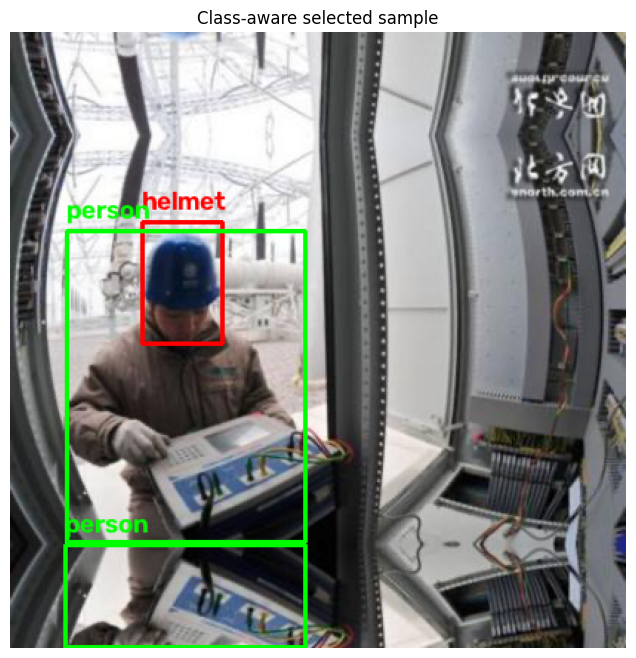

In [13]:
import cv2
import matplotlib.pyplot as plt

# Select the first image from the new class-aware selection
sample_image_file, sample_xml_file = selected_pairs[0]

image = cv2.imread(str(sample_image_file))

if image is None:
    raise ValueError("The sample image could not be read.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

tree = ET.parse(sample_xml_file)
root = tree.getroot()

for object_element in root.findall("object"):

    name_element = object_element.find("name")

    if name_element is None:
        continue

    class_name = name_element.text.strip().lower()

    if class_name not in {"person", "helmet", "head"}:
        continue

    box_element = object_element.find("bndbox")

    xmin = int(float(box_element.find("xmin").text))
    ymin = int(float(box_element.find("ymin").text))
    xmax = int(float(box_element.find("xmax").text))
    ymax = int(float(box_element.find("ymax").text))

    if class_name == "person":
        color = (0, 255, 0)
    elif class_name == "helmet":
        color = (255, 0, 0)
    else:
        color = (255, 165, 0)

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        color,
        2
    )

    cv2.putText(
        image,
        class_name,
        (xmin, max(ymin - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Class-aware selected sample")
plt.show()


In [14]:
import random
import xml.etree.ElementTree as ET

# Collect only image/XML pairs that contain at least one person annotation
person_pairs = []

for image_file, xml_file in matched_pairs:

    tree = ET.parse(xml_file)
    root = tree.getroot()

    has_person_annotation = False

    for object_element in root.findall("object"):

        name_element = object_element.find("name")

        if name_element is None:
            continue

        class_name = name_element.text.strip().lower()

        if class_name == "person":
            has_person_annotation = True
            break

    if has_person_annotation:
        person_pairs.append((image_file, xml_file))

print("Images containing person annotations:", len(person_pairs))


Images containing person annotations: 158


In [16]:
# Use a fixed seed for reproducible selection
random.seed(42)

# Randomize only the person-containing image pairs
random.shuffle(person_pairs)

# Select 150 clean image/XML pairs
selected_pairs = person_pairs[:150]

print("Final selected image/XML pairs:", len(selected_pairs))


Final selected image/XML pairs: 150


In [17]:
from collections import Counter

final_object_counts = Counter()
final_images_per_class = Counter()

for image_file, xml_file in selected_pairs:

    classes_in_image = set()

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for object_element in root.findall("object"):

        name_element = object_element.find("name")

        if name_element is None:
            continue

        class_name = name_element.text.strip().lower()

        if class_name in {"person", "helmet", "head"}:
            final_object_counts[class_name] += 1
            classes_in_image.add(class_name)

    for class_name in classes_in_image:
        final_images_per_class[class_name] += 1

print("Objects in final selected images:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{final_object_counts[class_name]} objects"
    )

print("\nImages containing each class:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{final_images_per_class[class_name]} images"
    )


Objects in final selected images:
person: 714 objects
helmet: 609 objects
head: 40 objects

Images containing each class:
person: 150 images
helmet: 150 images
head: 18 images


In [18]:
from pathlib import Path
import shutil
import random
import xml.etree.ElementTree as ET
from collections import Counter

# Define the final dataset folder
final_dataset_path = project_root / "final_dataset"

# Create the YOLO folder structure
for split_name in ["train", "val", "test"]:
    (final_dataset_path / "images" / split_name).mkdir(
        parents=True,
        exist_ok=True
    )
    (final_dataset_path / "labels" / split_name).mkdir(
        parents=True,
        exist_ok=True
    )

# Define the final class mapping
class_mapping = {
    "person": 0,
    "helmet": 1,
    "head": 2
}

# Shuffle selected pairs reproducibly
random.seed(42)
final_pairs = selected_pairs.copy()
random.shuffle(final_pairs)

# Create the 70/20/10 split
total_images = len(final_pairs)

train_count = int(total_images * 0.70)
val_count = int(total_images * 0.20)
test_count = total_images - train_count - val_count

train_pairs = final_pairs[:train_count]
val_pairs = final_pairs[train_count:train_count + val_count]
test_pairs = final_pairs[train_count + val_count:]

split_pairs = {
    "train": train_pairs,
    "val": val_pairs,
    "test": test_pairs
}

print("Train images:", len(train_pairs))
print("Validation images:", len(val_pairs))
print("Test images:", len(test_pairs))


Train images: 105
Validation images: 30
Test images: 15


In [19]:
def convert_voc_box_to_yolo(
    image_width,
    image_height,
    xmin,
    ymin,
    xmax,
    ymax
):
    """
    Convert Pascal VOC pixel coordinates
    into YOLO normalized coordinates.
    """

    box_width = xmax - xmin
    box_height = ymax - ymin

    x_center = xmin + box_width / 2
    y_center = ymin + box_height / 2
    yolo_width = box_width / image_width
    yolo_height = box_height / image_height

    x_center = x_center / image_width
    y_center = y_center / image_height

    return (
        x_center,
        y_center,
        yolo_width,
        yolo_height
    )


converted_object_counts = Counter()
invalid_box_count = 0
unknown_class_count = 0

for split_name, pairs in split_pairs.items():

    for image_file, xml_file in pairs:

        # Copy the image to its split folder
        output_image_path = (
            final_dataset_path
            / "images"
            / split_name
            / image_file.name
        )

        shutil.copy2(image_file, output_image_path)

        # Read the XML annotation
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Read image dimensions
        size_element = root.find("size")

        image_width = int(size_element.find("width").text)
        image_height = int(size_element.find("height").text)

        yolo_label_lines = []

        # Convert every annotated object
        for object_element in root.findall("object"):

            name_element = object_element.find("name")

            if name_element is None:
                continue

            class_name = name_element.text.strip().lower()

            # Skip classes outside the final mapping
            if class_name not in class_mapping:
                unknown_class_count += 1
                continue

            class_id = class_mapping[class_name]

            box_element = object_element.find("bndbox")

            xmin = float(box_element.find("xmin").text)
            ymin = float(box_element.find("ymin").text)
            xmax = float(box_element.find("xmax").text)
            ymax = float(box_element.find("ymax").text)

            # Keep coordinates within image boundaries
            xmin = max(0, min(xmin, image_width))
            ymin = max(0, min(ymin, image_height))
            xmax = max(0, min(xmax, image_width))
            ymax = max(0, min(ymax, image_height))

            # Ignore invalid boxes
            if xmax <= xmin or ymax <= ymin:
                invalid_box_count += 1
                continue

            (
                x_center,
                y_center,
                box_width,
                box_height
            ) = convert_voc_box_to_yolo(
                image_width,
                image_height,
                xmin,
                ymin,
                xmax,
                ymax
            )

            yolo_label_lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

            converted_object_counts[class_name] += 1

        # Save the YOLO label file
        output_label_path = (
            final_dataset_path
            / "labels"
            / split_name
            / f"{image_file.stem}.txt"
        )

        with open(output_label_path, "w") as file:
            file.write("\n".join(yolo_label_lines))

print("Pascal VOC to YOLO conversion completed.")
print("\nConverted object counts:")

for class_name in ["person", "helmet", "head"]:
    print(
        f"{class_name}: "
        f"{converted_object_counts[class_name]}"
    )

print("\nInvalid boxes:", invalid_box_count)
print("Unknown classes skipped:", unknown_class_count)


Pascal VOC to YOLO conversion completed.

Converted object counts:
person: 714
helmet: 609
head: 40

Invalid boxes: 0
Unknown classes skipped: 0


In [20]:
import yaml

# Create the YOLO dataset configuration
data_config = {
    "path": str(final_dataset_path),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "person",
        1: "helmet",
        2: "head"
    }
}

data_yaml_path = final_dataset_path / "data.yaml"

with open(data_yaml_path, "w") as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False
    )

print("data.yaml created successfully.")
print("Location:", data_yaml_path)

with open(data_yaml_path, "r") as file:
    print("\nFile content:")
    print(file.read())



data.yaml created successfully.
Location: /content/safety_helmet_project/final_dataset/data.yaml

File content:
path: /content/safety_helmet_project/final_dataset
train: images/train
val: images/val
test: images/test
names:
  0: person
  1: helmet
  2: head



In [21]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for split_name in ["train", "val", "test"]:

    image_folder = final_dataset_path / "images" / split_name
    label_folder = final_dataset_path / "labels" / split_name

    image_count = len([
        file
        for file in image_folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in image_extensions
    ])

    label_count = len(list(label_folder.glob("*.txt")))

    print(
        f"{split_name}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )


train: 105 images, 105 labels
val: 30 images, 30 labels
test: 15 images, 15 labels


In [22]:
invalid_label_lines = []

for split_name in ["train", "val", "test"]:

    label_folder = final_dataset_path / "labels" / split_name

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r") as file:
            lines = file.readlines()

        for line_number, line in enumerate(lines, start=1):

            values = line.strip().split()

            if len(values) != 5:
                invalid_label_lines.append(
                    (
                        str(label_file),
                        line_number,
                        "Expected 5 values"
                    )
                )
                continue

            class_id, x_center, y_center, width, height = map(
                float,
                values
            )

            if class_id not in [0, 1, 2]:
                invalid_label_lines.append(
                    (
                        str(label_file),
                        line_number,
                        "Invalid class ID"
                    )
                )

            coordinates = [
                x_center,
                y_center,
                width,
                height
            ]

            if any(value < 0 or value > 1 for value in coordinates):
                invalid_label_lines.append(
                    (
                        str(label_file),
                        line_number,
                        "Coordinate outside 0 to 1"
                    )
                )

print("Invalid label lines:", len(invalid_label_lines))

if invalid_label_lines:
    print(invalid_label_lines[:10])
else:
    print("All YOLO labels are valid.")


Invalid label lines: 0
All YOLO labels are valid.


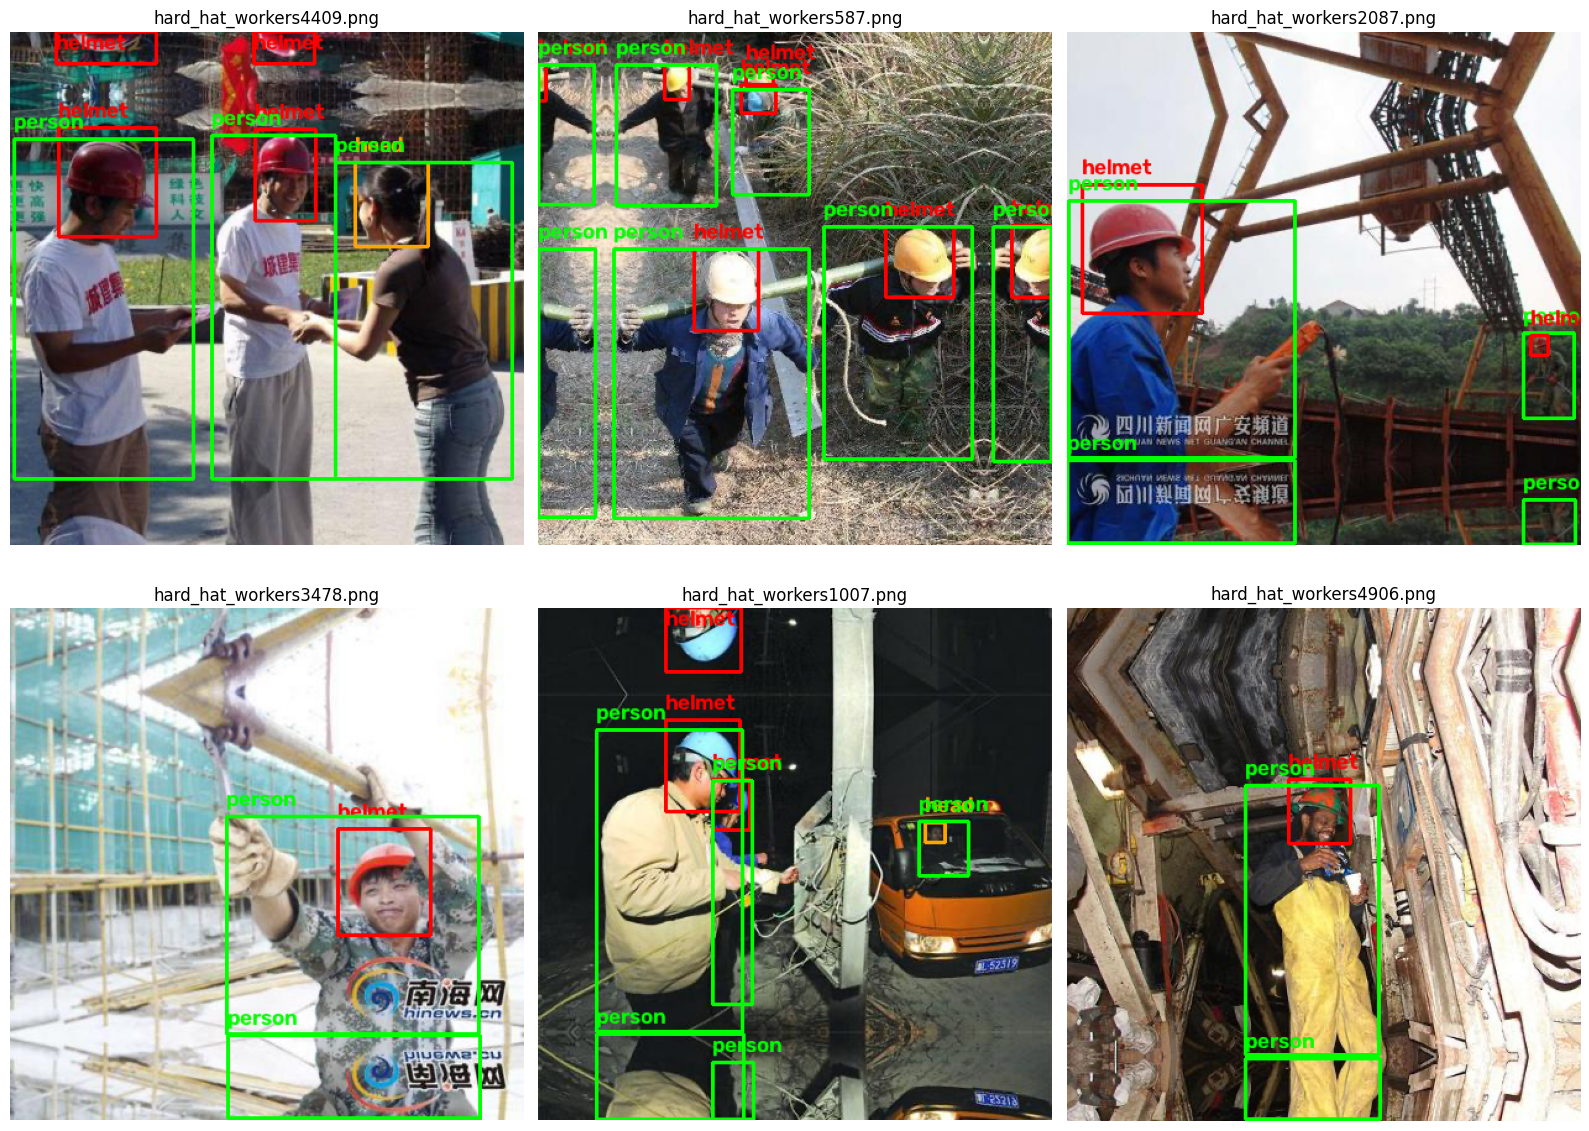

In [23]:
import cv2
import matplotlib.pyplot as plt
import random

# Define the final class names
class_names = ["person", "helmet", "head"]

# Select the training image and label folders
train_images_path = final_dataset_path / "images" / "train"
train_labels_path = final_dataset_path / "labels" / "train"

# Collect training images
train_images = [
    file
    for file in train_images_path.iterdir()
    if file.is_file()
    and file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
]

# Select six reproducible random samples
random.seed(42)
sample_images = random.sample(
    train_images,
    min(6, len(train_images))
)

plt.figure(figsize=(16, 12))

for plot_index, image_path in enumerate(sample_images, start=1):

    # Read and convert the image
    image = cv2.imread(str(image_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_height, image_width = image.shape[:2]

    # Locate the matching YOLO label file
    label_path = train_labels_path / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as file:
            label_lines = file.readlines()

        for line in label_lines:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id, x_center, y_center, box_width, box_height = map(
                float,
                values
            )

            # Convert normalized YOLO coordinates to pixels
            x_center_pixel = x_center * image_width
            y_center_pixel = y_center * image_height
            box_width_pixel = box_width * image_width
            box_height_pixel = box_height * image_height

            x1 = int(x_center_pixel - box_width_pixel / 2)
            y1 = int(y_center_pixel - box_height_pixel / 2)
            x2 = int(x_center_pixel + box_width_pixel / 2)
            y2 = int(y_center_pixel + box_height_pixel / 2)

            # Keep coordinates inside the image
            x1 = max(0, min(x1, image_width - 1))
            y1 = max(0, min(y1, image_height - 1))
            x2 = max(0, min(x2, image_width - 1))
            y2 = max(0, min(y2, image_height - 1))

            class_id = int(class_id)
            class_name = class_names[class_id]

            # Choose class colors
            if class_name == "person":
                color = (0, 255, 0)
            elif class_name == "helmet":
                color = (255, 0, 0)
            else:
                color = (255, 165, 0)

            # Draw the bounding box and class name
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                color,
                2
            )

            cv2.putText(
                image,
                class_name,
                (x1, max(y1 - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    # Display the sample
    plt.subplot(2, 3, plot_index)
    plt.imshow(image)
    plt.title(image_path.name[:25])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [24]:
import torch

# Check whether a GPU is available
gpu_available = torch.cuda.is_available()

print("GPU available:", gpu_available)

if gpu_available:
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Training will run on CPU.")


GPU available: False
Training will run on CPU.


In [25]:
from ultralytics import YOLO
from pathlib import Path

# Load the pretrained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Train on CPU
training_results = model.train(
    data=str(data_yaml_path),
    epochs=30,
    imgsz=640,
    batch=4,
    device="cpu",
    project=str(outputs_path),
    name="helmet_detection_yolov8n_cpu",
    patience=10,
    workers=0,
    plots=True,
    verbose=True
)

print("CPU training completed successfully.")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/safety_helmet_project/final_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format

In [26]:
from pathlib import Path

# Define the best trained model path
best_model_path = (
    outputs_path
    / "helmet_detection_yolov8n_cpu"
    / "weights"
    / "best.pt"
)

print("Best model exists:", best_model_path.exists())
print("Best model path:", best_model_path)


Best model exists: True
Best model path: /content/safety_helmet_project/outputs/helmet_detection_yolov8n_cpu/weights/best.pt


In [27]:
from ultralytics import YOLO

# Load the best trained model
best_model = YOLO(str(best_model_path))

# Evaluate on the test split
test_results = best_model.val(
    data=str(data_yaml_path),
    split="test",
    imgsz=640,
    batch=4,
    device="cpu",
    plots=True,
    project=str(outputs_path),
    name="test_evaluation"
)

print("Test evaluation completed.")


Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 581.6±53.7 MB/s, size: 270.6 KB)
val: Scanning /content/safety_helmet_project/final_dataset/labels/test... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 763.7it/s 0.0s
val: New cache created: /content/safety_helmet_project/final_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.1s/it 8.5s
                   all         15        199       0.82      0.418      0.467      0.263
                person         15        100      0.672       0.54      0.599      0.301
                helmet         15         87      0.789      0.713      0.779      0.484
                  head          3         12          1          0     0.0223    0.00584
Speed: 6.0ms preprocess, 376.8ms i

In [28]:
 # Run inference on the test images
prediction_results = best_model.predict(
    source=str(final_dataset_path / "images" / "test"),
    imgsz=640,
    conf=0.25,
    device="cpu",
    save=True,
    save_txt=True,
    project=str(outputs_path),
    name="test_predictions"
)

print("Test predictions completed.")
print("Prediction folder:")
print(outputs_path / "test_predictions")



image 1/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers1022.png: 640x640 7 persons, 2 helmets, 317.7ms
image 2/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers1351.png: 640x640 6 helmets, 324.2ms
image 3/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers2409.png: 640x640 2 persons, 2 helmets, 444.3ms
image 4/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers2517.png: 640x640 24 persons, 12 helmets, 342.6ms
image 5/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers3087.png: 640x640 6 persons, 5 helmets, 451.4ms
image 6/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers3241.png: 640x640 2 persons, 2 helmets, 270.8ms
image 7/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers3862.png: 640x640 2 persons, 2 helmets, 336.1ms
image 8/15 /content/safety_helmet_project/final_dataset/images/test/hard_hat_workers

Prediction images found: 15


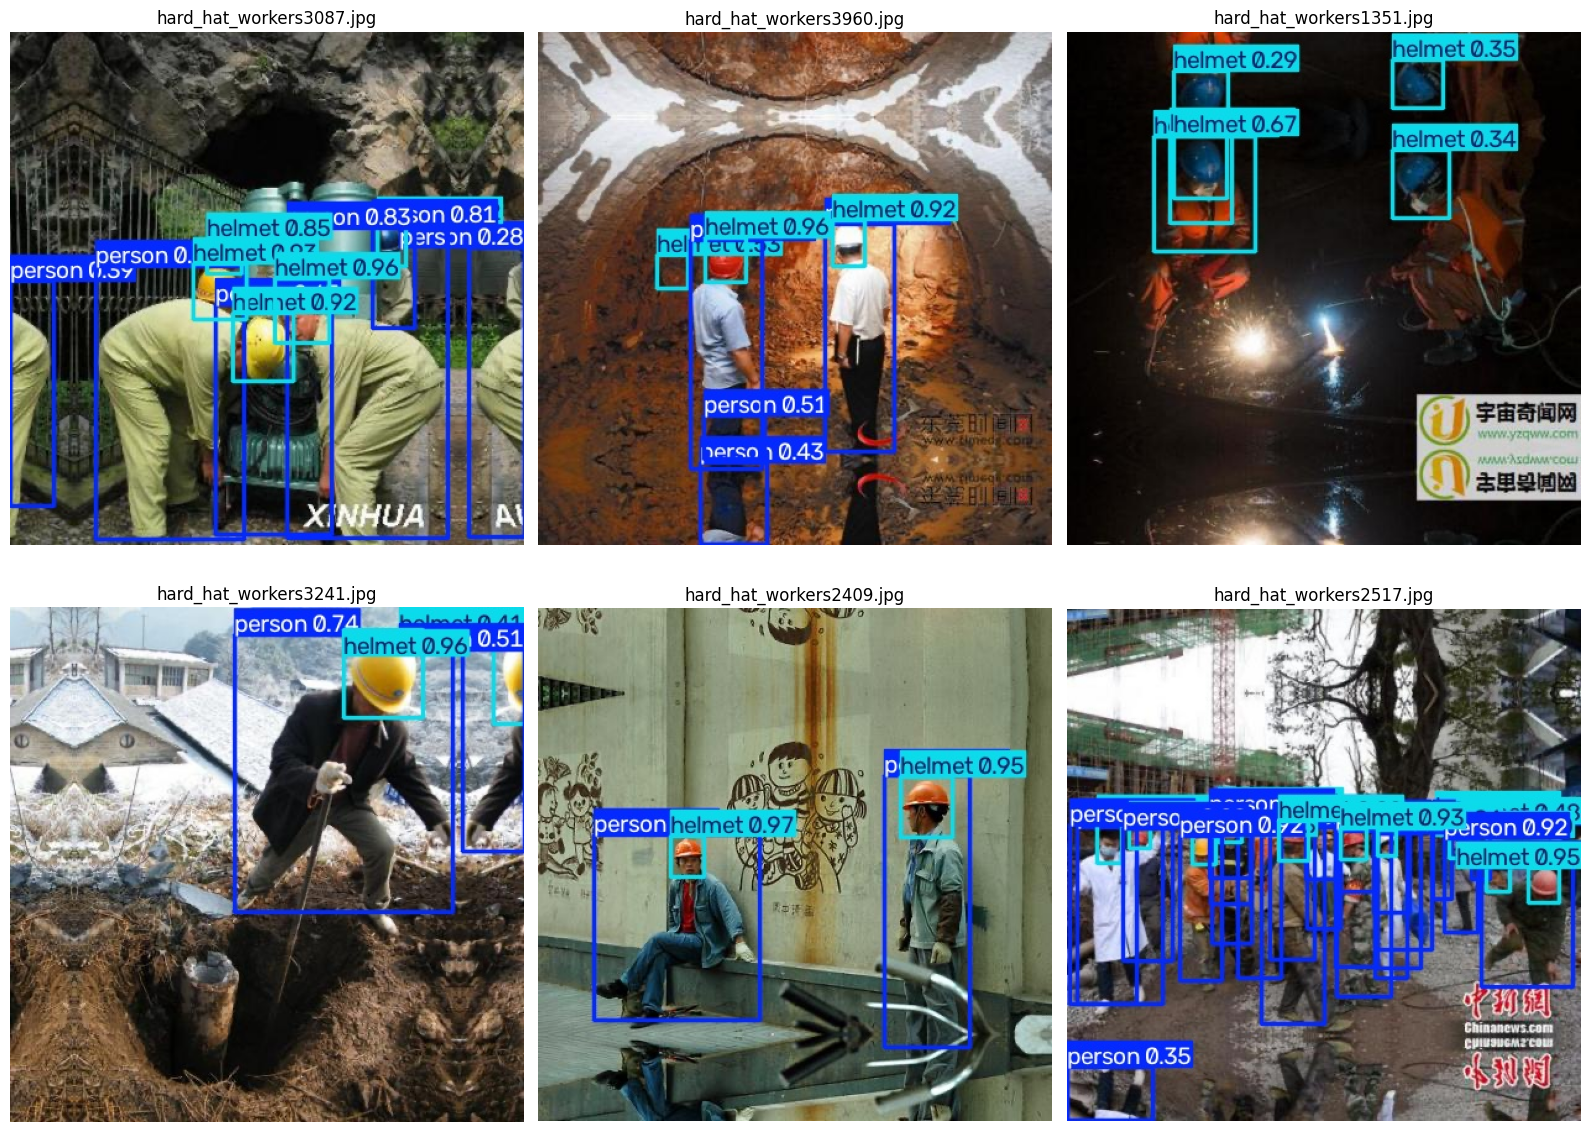

In [29]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

# Define prediction folders
prediction_images_path = (
    outputs_path / "test_predictions"
)

# Collect saved prediction images
prediction_images = [
    file
    for file in prediction_images_path.iterdir()
    if file.is_file()
    and file.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Prediction images found:", len(prediction_images))

# Select up to six prediction images
random.seed(42)
sample_predictions = random.sample(
    prediction_images,
    min(6, len(prediction_images))
)

plt.figure(figsize=(16, 12))

for plot_index, image_path in enumerate(sample_predictions, start=1):

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, plot_index)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [30]:
from pathlib import Path

# Define the report folder
report_path = project_root / "reports"
report_path.mkdir(parents=True, exist_ok=True)

# Write the final experiment summary
summary_text = """
Safety Helmet Detection - Final Experiment Summary

Dataset:
- Source: Hard Hat Detection dataset
- Original annotation format: Pascal VOC XML
- Final annotation format: YOLO TXT
- Final classes: person, helmet, head
- Total images: 150

Dataset split:
- Training images: 105
- Validation images: 30
- Test images: 15

Model:
- YOLOv8n
- Image size: 640
- Epochs: 30
- Device: CPU
- Batch size: 4

Validation performance:
- Precision: 0.838
- Recall: 0.446
- mAP@0.5: 0.511
- mAP@0.5:0.95: 0.283

Test performance:
- Precision: 0.820
- Recall: 0.418
- mAP@0.5: 0.467
- mAP@0.5:0.95: 0.263

Test performance by class:
- Person mAP@0.5: 0.599
- Helmet mAP@0.5: 0.779
- Head mAP@0.5: 0.022

Main limitation:
- The head class was underrepresented, so head detection performance was weak.
- The dataset used existing annotations that were converted and visually verified.
- Additional manual annotation and class balancing would improve the project.
"""

summary_file = report_path / "experiment_summary.txt"

with open(summary_file, "w") as file:
    file.write(summary_text)

print("Experiment summary saved to:")
print(summary_file)


Experiment summary saved to:
/content/safety_helmet_project/reports/experiment_summary.txt


In [34]:
from pathlib import Path

# Create the reports folder
report_path = project_root / "reports"
report_path.mkdir(parents=True, exist_ok=True)

# Store the report as separate text lines
report_lines = [
    "# Safety Helmet Detection Using YOLOv8",
    "",
    "## 1. Project Overview",
    "",
    "This project implements an object detection system for workplace safety images.",
    "The system detects three classes: person, helmet, and head.",
    "",
    "## 2. Problem Statement",
    "",
    "The goal is to detect persons, helmets, and visible head regions in workplace and construction-site images.",
    "",
    "## 3. Dataset",
    "",
    "The Hard Hat Detection dataset was used.",
    "The original Pascal VOC XML annotations were converted into YOLO TXT format.",
    "A total of 150 images were selected.",
    "",
    "## 4. Class Mapping",
    "",
    "| Class ID | Class Name |",
    "|---:|---|",
    "| 0 | person |",
    "| 1 | helmet |",
    "| 2 | head |",
    "",
    "The head class represents a visible head region according to the original dataset annotation.",
    "It is not automatically treated as a no_helmet class.",
    "",
    "## 5. Dataset Split",
    "",
    "| Split | Images | Percentage |",
    "|---|---:|---:|",
    "| Train | 105 | 70% |",
    "| Validation | 30 | 20% |",
    "| Test | 15 | 10% |",
    "| Total | 150 | 100% |",
    "",
    "## 6. Annotation Conversion",
    "",
    "Pascal VOC XML annotations were converted into YOLO format:",
    "",
    "class_id x_center y_center width height",
    "",
    "All coordinates were normalized between 0 and 1.",
    "There were no invalid boxes and no invalid YOLO label lines.",
    "",
    "## 7. Model and Training",
    "",
    "| Setting | Value |",
    "|---|---|",
    "| Model | YOLOv8n |",
    "| Epochs | 30 |",
    "| Image size | 640 |",
    "| Batch size | 4 |",
    "| Device | CPU |",
    "",
    "## 8. Validation Results",
    "",
    "| Metric | Value |",
    "|---|---:|",
    "| Precision | 0.838 |",
    "| Recall | 0.446 |",
    "| mAP@0.5 | 0.511 |",
    "| mAP@0.5:0.95 | 0.283 |",
    "",
    "## 9. Test Results",
    "",
    "| Class | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 |",
    "|---|---:|---:|---:|---:|",
    "| Person | 0.672 | 0.540 | 0.599 | 0.301 |",
    "| Helmet | 0.789 | 0.713 | 0.779 | 0.484 |",
    "| Head | 1.000 | 0.000 | 0.022 | 0.00584 |",
    "| Overall | 0.820 | 0.418 | 0.467 | 0.263 |",
    "",
    "## 10. Inference",
    "",
    "Inference was performed on all 15 test images.",
    "Prediction images and prediction labels were saved in the test prediction folder.",
    "",
    "## 11. Error Analysis",
    "",
    "The helmet class achieved the strongest performance.",
    "Person detection was moderate.",
    "The head class performed poorly because it was underrepresented.",
    "Main errors included missed persons, loose boxes, overlapping boxes, and weak head predictions.",
    "",
    "## 12. Limitations",
    "",
    "The project used 150 images because the assignment allows 150 to 300 images.",
    "The head class had relatively few examples.",
    "Training was performed on CPU because GPU access was unavailable in Google Colab.",
    "The existing annotations were converted and visually reviewed rather than completely redrawn from scratch.",
    "",
    "## 13. Future Improvements",
    "",
    "Future work should include more balanced head examples, additional annotation review, a larger dataset, stronger augmentation, GPU-based training, and experiments with larger YOLO models.",
    "",
    "## 14. Conclusion",
    "",
    "A complete YOLOv8 object detection pipeline was implemented.",
    "The project included dataset preparation, annotation conversion, validation, training, evaluation, inference, and error analysis.",
    "The model performed best on helmet detection and achieved moderate person detection performance."
]

# Join all lines into one Markdown document
report_text = "\n".join(report_lines)

# Save the report
report_file = report_path / "final_project_report.md"

with open(report_file, "w", encoding="utf-8") as file:
    file.write(report_text)

print("Final report saved successfully.")
print("Report path:", report_file)
print("Report exists:", report_file.exists())


Final report saved successfully.
Report path: /content/safety_helmet_project/reports/final_project_report.md
Report exists: True


In [35]:
from pathlib import Path
import shutil

# Define the final submission folder
submission_path = Path("/content/safety_helmet_submission")

# Remove an old submission folder if it exists
if submission_path.exists():
    shutil.rmtree(submission_path)

submission_path.mkdir(parents=True, exist_ok=True)

# Copy the final YOLO dataset
shutil.copytree(
    final_dataset_path,
    submission_path / "dataset"
)

# Copy the best trained model
best_model_source = (
    outputs_path
    / "helmet_detection_yolov8n_cpu"
    / "weights"
    / "best.pt"
)

shutil.copy2(
    best_model_source,
    submission_path / "best.pt"
)

# Copy the final report
shutil.copy2(
    report_path / "final_project_report.md",
    submission_path / "final_project_report.md"
)

# Copy the experiment summary
shutil.copy2(
    report_path / "experiment_summary.txt",
    submission_path / "experiment_summary.txt"
)

# Copy test evaluation results
test_evaluation_path = outputs_path / "test_evaluation"

if test_evaluation_path.exists():
    shutil.copytree(
        test_evaluation_path,
        submission_path / "test_evaluation"
    )

# Copy test prediction results
test_predictions_path = outputs_path / "test_predictions"

if test_predictions_path.exists():
    shutil.copytree(
        test_predictions_path,
        submission_path / "test_predictions"
    )

print("Submission folder created successfully.")
print("Submission path:", submission_path)


Submission folder created successfully.
Submission path: /content/safety_helmet_submission


In [36]:
# Verify important submission files
important_files = [
    submission_path / "dataset" / "data.yaml",
    submission_path / "best.pt",
    submission_path / "final_project_report.md",
    submission_path / "experiment_summary.txt"
]

for file_path in important_files:
    print(
        file_path,
        "->",
        "Exists" if file_path.exists() else "Missing"
    )


/content/safety_helmet_submission/dataset/data.yaml -> Exists
/content/safety_helmet_submission/best.pt -> Exists
/content/safety_helmet_submission/final_project_report.md -> Exists
/content/safety_helmet_submission/experiment_summary.txt -> Exists


In [37]:
# Create a ZIP archive of the final submission folder
submission_zip_path = shutil.make_archive(
    "/content/safety_helmet_submission",
    "zip",
    submission_path
)

print("Submission ZIP created successfully.")
print("ZIP path:", submission_zip_path)


Submission ZIP created successfully.
ZIP path: /content/safety_helmet_submission.zip


In [38]:
from google.colab import files

# Download the final submission ZIP
files.download(submission_zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>